# LAB 1
En este lab repasaremos los conceptos vistos en la clase 2 Fundamentos de Riesgo y Rendimientos

## Bibliotecas a importar

* yfinance: la usaremos para descargar información
* numpy: la usaremos para realizar diversas operaciones matemáticas
* pandas: la usaremos para realizar cálculos con vectores
* analisis_portafolios: nuestra biblioteca del curso que tendrá funciones para los procedimientos vistos en clase

In [1]:
import yfinance as yf
import numpy as np
import analisis_portafolios as ap

## Descargamos la información a analizar

In [2]:
ticker = "AAPL" # ticker de la acción a analizar
fecha_inicio = "2025-01-01" # fecha de inicio para descargar
fecha_fin = "2025-12-31" # fecha final para descargar

In [3]:
datos = yf.download(ticker, start=fecha_inicio, end=fecha_fin)

[*********************100%***********************]  1 of 1 completed


In [4]:
# visualizamos informacion descargada
datos.head()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2025-01-02,242.093140,247.305315,240.077766,247.136526,55740700
2025-01-03,241.606644,242.420728,240.147234,241.606644,40244100
2025-01-06,243.234818,245.548032,241.447783,242.549786,45045600
2025-01-07,240.464951,243.780883,239.611146,241.229392,40856000
2025-01-08,240.951401,241.954134,238.320499,240.177022,37628900


El resultado es una tabla que tiene 5 columnas y cada fila corresponde a un día de operación:

* Close: Precio de cierre
* High: Precio máximo del día
* Low: Precio mínimo del día
* Open: Precio de apertura
* Volume: Número de acciones que se intercambiaron en el día (compra o venta)

In [5]:
# extraemos la columna que nos interesa analizar
precio_cierre = datos[("Close", "AAPL")]
precio_cierre.head()

Date
2025-01-02    242.093140
2025-01-03    241.606644
2025-01-06    243.234818
2025-01-07    240.464951
2025-01-08    240.951401
Name: (Close, AAPL), dtype: float64

## Descargar múltiples datos
También es posible descargar información de diferentes empresas en un sólo llamado

In [6]:
datos_multiples = yf.download(["AAPL", "TSLA"], start=fecha_inicio, end=fecha_fin)

[*********************100%***********************]  2 of 2 completed


In [7]:
datos_multiples.head()

Price            Close                    High                     Low  \
Ticker            AAPL        TSLA        AAPL        TSLA        AAPL   
Date                                                                     
2025-01-02  242.093140  379.279999  247.305315  392.730011  240.077766   
2025-01-03  241.606644  410.440002  242.420728  411.880005  240.147234   
2025-01-06  243.234818  411.049988  245.548032  426.429993  241.447783   
2025-01-07  240.464951  394.359985  243.780883  414.329987  239.611146   
2025-01-08  240.951401  394.940002  241.954134  402.500000  238.320499   

Price                         Open                Volume             
Ticker            TSLA        AAPL        TSLA      AAPL       TSLA  
Date                                                                 
2025-01-02  373.040009  247.136526  390.100006  55740700  109710700  
2025-01-03  379.450012  241.606644  381.480011  40244100   95423300  
2025-01-06  401.700012  242.549786  423.200012  45045600   85516500  
2025-01-07  390.000000  241.229392  405.829987  40856000   75699500  
2025-01-08  387.399994  240.177022  392.950012  37628900   73038800

## Riesgo y Rendimiento

Para calcular el riesgo y el rendimiento usaremos los precios de cierre como base.

<Axes: xlabel='Date'>

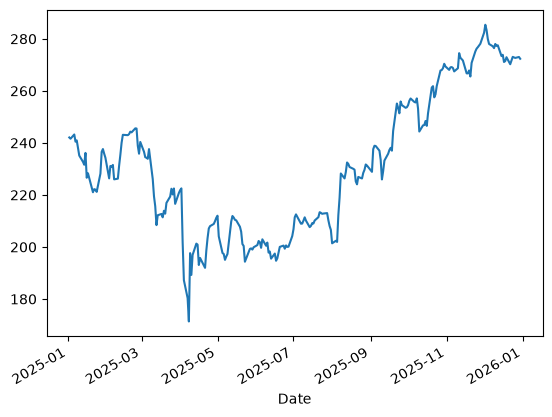

In [8]:
# visualizamos el precio de cierre
precio_cierre.plot()

### Rendimientos porcentuales

Calcular los rendimientos porcentuales es muy sencillo si ya tenemos los precios de cierre. Sólo tenemos utilizar la función "pct_change". La cual realiza la siguiente operación:

$$ R_t=\frac{P_t-P_{t-1}}{P_t} $$

A este rendimiento se le conoce como *rendimiento aritmético simple*.

In [9]:
rend_simple = precio_cierre.pct_change()

In [10]:
rend_simple.head()

Date
2025-01-02         NaN
2025-01-03   -0.002010
2025-01-06    0.006739
2025-01-07   -0.011388
2025-01-08    0.002023
Name: (Close, AAPL), dtype: float64

<Axes: xlabel='Date'>

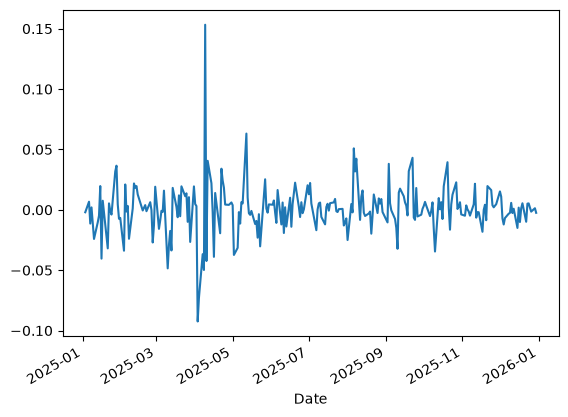

In [11]:
rend_simple.plot()

In [12]:
rend_simple.describe()

count    248.000000
mean       0.000681
std        0.020489
min       -0.092456
25%       -0.006729
50%        0.000791
75%        0.006617
max        0.153288
Name: (Close, AAPL), dtype: float64

### Rendimientos logarítmicos

También podemos calcular los rendimientos logarítmicos:

$$ R_{log} = ln(\frac{P_t}{P_{t-1}})$$

In [13]:
rend_log = np.log(precio_cierre / precio_cierre.shift(1))

In [14]:
rend_log.head()

Date
2025-01-02         NaN
2025-01-03   -0.002012
2025-01-06    0.006716
2025-01-07   -0.011453
2025-01-08    0.002021
Name: (Close, AAPL), dtype: float64

<Axes: xlabel='Date'>

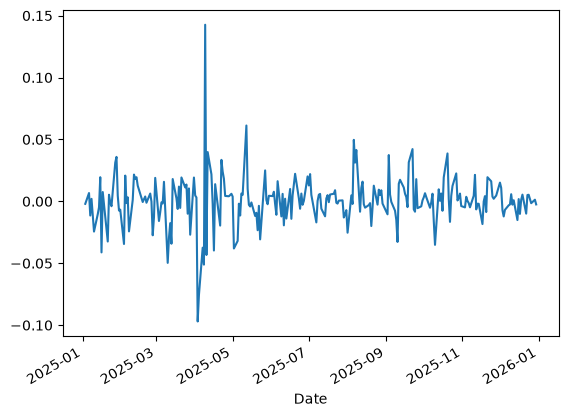

In [15]:
rend_log.plot()

### Rendimiento anualizado
Ahora que ya hemos calculado el rendimiento diario procederemos a calcular el rendimiento anualizado.

**NOTA:** Previamente realizamos dos métodos para obtener los rendimientos diarios (el porcentual y el logaritmico), utilizaremos el porcentual al menos que se especifique lo contrario.

In [16]:
ap.rendimiento_anualizado(rend_simple)

np.float64(0.1265303259954489)

**NOTA**: 
* De manera predeterminada se tendrá que $p=252$ dado que ese es el número aproximado de días de operación de la Bolsa de Valores en 1 año (pues opera de lunes a viernes $ 365 * \frac{5}{7} \approx 261 $ y se consideran $9$ días festivos en Estados Unidos).
* En caso de que la periodicidad de nuestros rendimientos no sea diaria habría que modificar la $p$. Por ejemplo: Si nuestros rendimientos son mensuales usaríamos $p=12$.

### Volatilidad anualizada

In [17]:
ap.volatilidad_anualizada(rend_simple)

np.float64(0.32525599744204714)